# Full-Trace Analysis — Emotional vs Neutral

Analyze only E (emotional) and N (neutral) whole-trace observations from
the three batch folders in `dataNEW/` (including nested directories). Each row
represents one whole trace. Joy is excluded. The original four throttle features
are supplemented with the whole-trace throttle-to-cycles ratio.

Bonferroni correction covers **5 features × 1 condition pair = 5 tests**,
separately for Welch and Mann–Whitney. Raw and corrected p-values are shown.
This E–N-focused analysis was requested after inspecting the three-class results;
it is exploratory, not a newly prespecified confirmatory analysis. Tests treat
traces as independent; repeated runs on the same node may be dependent.


The ratio is `sum(core_power.throttle) / sum(cycles)`, computed here as
`core_power.throttle__mean_rate / cycles__mean_rate`: both stored rates use the
same trace duration, which cancels. This is a ratio of totals, not a mean of
interval ratios. Equivalence assumes both counters cover the same valid
intervals; the extracted feature CSVs do not establish that coverage. Invalid
rates and nonpositive cycle denominators are rejected. The measure is reported
as a dimensionless ratio, without asserting an exact physical percentage.
Normalization does not remove batch, instruction-mix, or repeated-node effects.


In [17]:
%matplotlib inline
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, ttest_ind

# ── Configuration ──────────────────────────────────────────────────────────
BASE_DIR = next(p for p in [Path.cwd(), *Path.cwd().parents]
                if (p / 'dataNEW').is_dir())
DATA_DIR = BASE_DIR / 'dataNEW'
# Accept either spelling of the old-batch directory, but reject ambiguity.
old_candidates = [DATA_DIR / name for name in ('fulltrace_0ld_batch', 'fulltrace_old_batch')
                  if (DATA_DIR / name).is_dir()]
if len(old_candidates) != 1:
    raise ValueError('Expected exactly one fulltrace_0ld_batch or fulltrace_old_batch directory.')
BATCH_DIRS = {
    'old': old_candidates[0],
    #'first': DATA_DIR / 'fulltrace_1st_batch',
   # 'second': DATA_DIR / 'fulltrace_2nd_batch',
}
RESULTS_DIR = DATA_DIR / 'analysis_EN'
RESULTS_DIR.mkdir(exist_ok=True)

BASE_FEATURES = [
    'core_power.throttle__mean_rate',
    'core_power.throttle__variance',
    'core_power.throttle__spectral_entropy',
    'core_power.throttle__slope',
]

RATIO_FEATURE = 'core_power.throttle__per_cycle'
FEATURES = [*BASE_FEATURES, RATIO_FEATURE]
SHORT = {f: f.split('__')[-1] for f in FEATURES}
SHORT[RATIO_FEATURE] = 'throttle_per_cycle'

SEED = 42

print('Configuration OK')
CONDITIONS = ['neutral', 'emotional']
PAIRS = list(combinations(CONDITIONS, 2))
CODES = {'neutral': 'N', 'emotional': 'E'}
COLORS = {'neutral': '#777777', 'emotional': '#C44E52'}

Configuration OK


## §1 — Load all three batches

Discover individual CSVs recursively inside the configured batches, including the
nested `fulltrace_2nd_batch/2nd_batch` directory. Require unique run labels and
valid features. Validate any local `all_whole.csv` against its corresponding
individual files. Export the pooled input with batch/source provenance and a
batch-by-condition count table. Tests and plots below pool these rows.

Exclude joy after validating source files and aggregates, then derive the ratio for E/N traces.

In [18]:
frames = []
verified_aggregates = []
for batch, batch_dir in BATCH_DIRS.items():
    if not batch_dir.is_dir():
        raise ValueError(f'Missing batch directory: {batch_dir}')
    whole_csvs = sorted(p for p in batch_dir.rglob('*_whole.csv') if p.name != 'all_whole.csv')
    if not whole_csvs:
        raise ValueError(f'No individual whole-trace CSVs in {batch_dir}')
    batch_frames = []
    for path in whole_csvs:
        # E in a run name (e.g. 222E1) must not be parsed as scientific notation.
        frame = pd.read_csv(path, dtype={'run_label': str, 'condition': str})
        required = ['run_label', 'condition', 'mode', *BASE_FEATURES, 'cycles__mean_rate']
        missing = [column for column in required if column not in frame]
        if missing:
            raise ValueError(f'{path}: missing columns {missing}')
        if len(frame) != 1:
            raise ValueError(f'{path}: expected exactly one whole-trace row')
        if frame.run_label.isna().any() or frame.run_label.iloc[0] != path.name.removesuffix('_whole.csv'):
            raise ValueError(f'{path}: missing run label or mismatch with filename')
        frame['batch'] = batch
        frame['source_file'] = str(path.relative_to(BASE_DIR))
        batch_frames.append(frame)
    batch_df = pd.concat(batch_frames, ignore_index=True)
    if batch_df.run_label.duplicated().any():
        raise ValueError(f'Duplicate run labels within batch {batch}')
    # Check each local aggregate against individual CSVs under its directory.
    # A root aggregate from a previous layout is deliberately not used.
    for combined_path in sorted(batch_dir.rglob('all_whole.csv')):
        scoped_paths = {str(p.relative_to(BASE_DIR)) for p in whole_csvs
                        if p.is_relative_to(combined_path.parent)}
        expected = batch_df.loc[batch_df.source_file.isin(scoped_paths)].drop(columns=['batch', 'source_file'])
        combined = pd.read_csv(combined_path, dtype={'run_label': str, 'condition': str})
        pd.testing.assert_frame_equal(
            expected.sort_values('run_label').reset_index(drop=True),
            combined.sort_values('run_label').reset_index(drop=True),
            check_dtype=False, obj=str(combined_path),
        )
        verified_aggregates.append(str(combined_path.relative_to(BASE_DIR)))
    frames.append(batch_df)

df = pd.concat(frames, ignore_index=True)
# Reject ambiguous repeated run names rather than silently count copies as new traces.
if df.run_label.duplicated().any():
    duplicates = df.loc[df.run_label.duplicated(False), ['run_label', 'batch', 'source_file']]
    raise ValueError(f'Run labels repeated across batches; resolve provenance before pooling:\n{duplicates}')
if not df.condition.isin(['neutral', 'emotional', 'joy']).all():
    raise ValueError('Unexpected condition in source data')
excluded = df.loc[~df.condition.isin(CONDITIONS), 'condition'].value_counts()
print('Excluded conditions:', excluded.to_dict())
df = df.loc[df.condition.isin(CONDITIONS)].copy().reset_index(drop=True)
rates = df[['core_power.throttle__mean_rate', 'cycles__mean_rate']].to_numpy(dtype=float)
if not np.isfinite(rates).all() or (rates[:, 0] < 0).any() or (rates[:, 1] <= 0).any():
    raise ValueError('Ratio requires finite nonnegative throttle rates and positive cycle rates')
df[RATIO_FEATURE] = rates[:, 0] / rates[:, 1]
if set(df.condition) != set(CONDITIONS):
    raise ValueError(f'Unexpected or missing conditions: {set(df.condition)}')
if not df['mode'].eq('whole_trace').all():
    raise ValueError('Expected whole-trace rows only')
if not np.isfinite(df[FEATURES].to_numpy(dtype=float)).all():
    raise ValueError('Nonfinite selected feature values')
counts = df.condition.value_counts().reindex(CONDITIONS)
batch_counts = pd.crosstab(df.batch, df.condition).reindex(
    index=list(BATCH_DIRS), columns=CONDITIONS, fill_value=0)
print(f'Data: {DATA_DIR}')
print('Batch × condition counts:')
print(batch_counts.to_string())
print('Total traces per condition:')
print(counts.to_string())
print(f'{len(df)} unique whole traces; {len(FEATURES)} features')
print('Verified local aggregates:', verified_aggregates)
df.to_csv(RESULTS_DIR / 'pooled_whole_traces.csv', index=False)
batch_counts.to_csv(RESULTS_DIR / 'batch_condition_counts.csv')


Excluded conditions: {}
Data: /Users/rsalvi/Desktop/mccviahat/dataNEW
Batch × condition counts:
condition  neutral  emotional
batch                        
old             20         20
Total traces per condition:
condition
neutral      20
emotional    20
40 unique whole traces; 5 features
Verified local aggregates: []


## §2 — Per-feature univariate tests

Compare N–E for each of the five features using descriptive
statistics, Welch two-sample t-tests, two-sided Mann–Whitney U tests, and the
original notebook's absolute standardized mean difference (the denominator is
the square root of the mean of the two sample variances, labeled `cohens_d`).
Bonferroni correction uses 5 comparisons separately within each test family.
Plot stars use corrected Mann–Whitney p-values. Both test families are reported;
the correction does not combine them into one family.


In [19]:
results = []
for feat in FEATURES:
    for left, right in PAIRS:
        a = df.loc[df.condition == left, feat].dropna().values
        b = df.loc[df.condition == right, feat].dropna().values
        if len(a) < 2 or len(b) < 2:
            raise ValueError(f'Need at least two values for {feat}: {left}/{right}')
        a_mean, a_std = np.mean(a), np.std(a, ddof=1)
        b_mean, b_std = np.mean(b), np.std(b, ddof=1)
        pooled_std = np.sqrt((a_std**2 + b_std**2) / 2)
        t_stat, t_p = ttest_ind(a, b, equal_var=False)
        u_stat, mwu_p = mannwhitneyu(a, b, alternative='two-sided')
        results.append(dict(
            feature=SHORT[feat], left=left, right=right,
            pair=f'{CODES[left]}–{CODES[right]}',
            direction='↑' + CODES[left if a_mean > b_mean else right],
            left_mean=a_mean, left_std=a_std, right_mean=b_mean, right_std=b_std,
            cohens_d=abs(a_mean-b_mean)/pooled_std if pooled_std > 0 else np.nan,
            t_stat=t_stat, t_p=t_p, U=u_stat, mwu_p=mwu_p))
res_df = pd.DataFrame(results)
n_tests = len(results)
res_df['t_p_corr'] = (res_df['t_p'] * n_tests).clip(upper=1.0)
res_df['mwu_p_corr'] = (res_df['mwu_p'] * n_tests).clip(upper=1.0)
print(f'Per-feature tests ({counts.to_dict()}, Bonferroni k={n_tests})')
print(res_df.to_string(index=False))
res_df.to_csv(RESULTS_DIR / 'pairwise_tests.csv', index=False)


Per-feature tests ({'neutral': 20, 'emotional': 20}, Bonferroni k=5)
           feature    left     right pair direction    left_mean     left_std   right_mean    right_std  cohens_d    t_stat      t_p     U    mwu_p  t_p_corr  mwu_p_corr
         mean_rate neutral emotional  N–E        ↑E 1.138559e+09 6.541990e+07 1.178117e+09 5.580286e+07  0.650610 -2.057410 0.046731 101.0 0.007712  0.233653    0.038559
          variance neutral emotional  N–E        ↑E 3.616646e+13 8.533050e+12 3.709028e+13 8.520665e+12  0.108342 -0.342608 0.733781 190.0 0.797197  1.000000    1.000000
  spectral_entropy neutral emotional  N–E        ↑E 9.054834e-01 2.397043e-02 9.187168e-01 1.859499e-02  0.616891 -1.950780 0.058947 136.0 0.085855  0.294737    0.429274
             slope neutral emotional  N–E        ↑N 1.222694e+01 6.923071e+00 1.174874e+01 4.565787e+00  0.081548  0.257877 0.798108 184.0 0.675014  1.000000    1.000000
throttle_per_cycle neutral emotional  N–E        ↑E 8.743935e-03 5.593282e-04 9.1

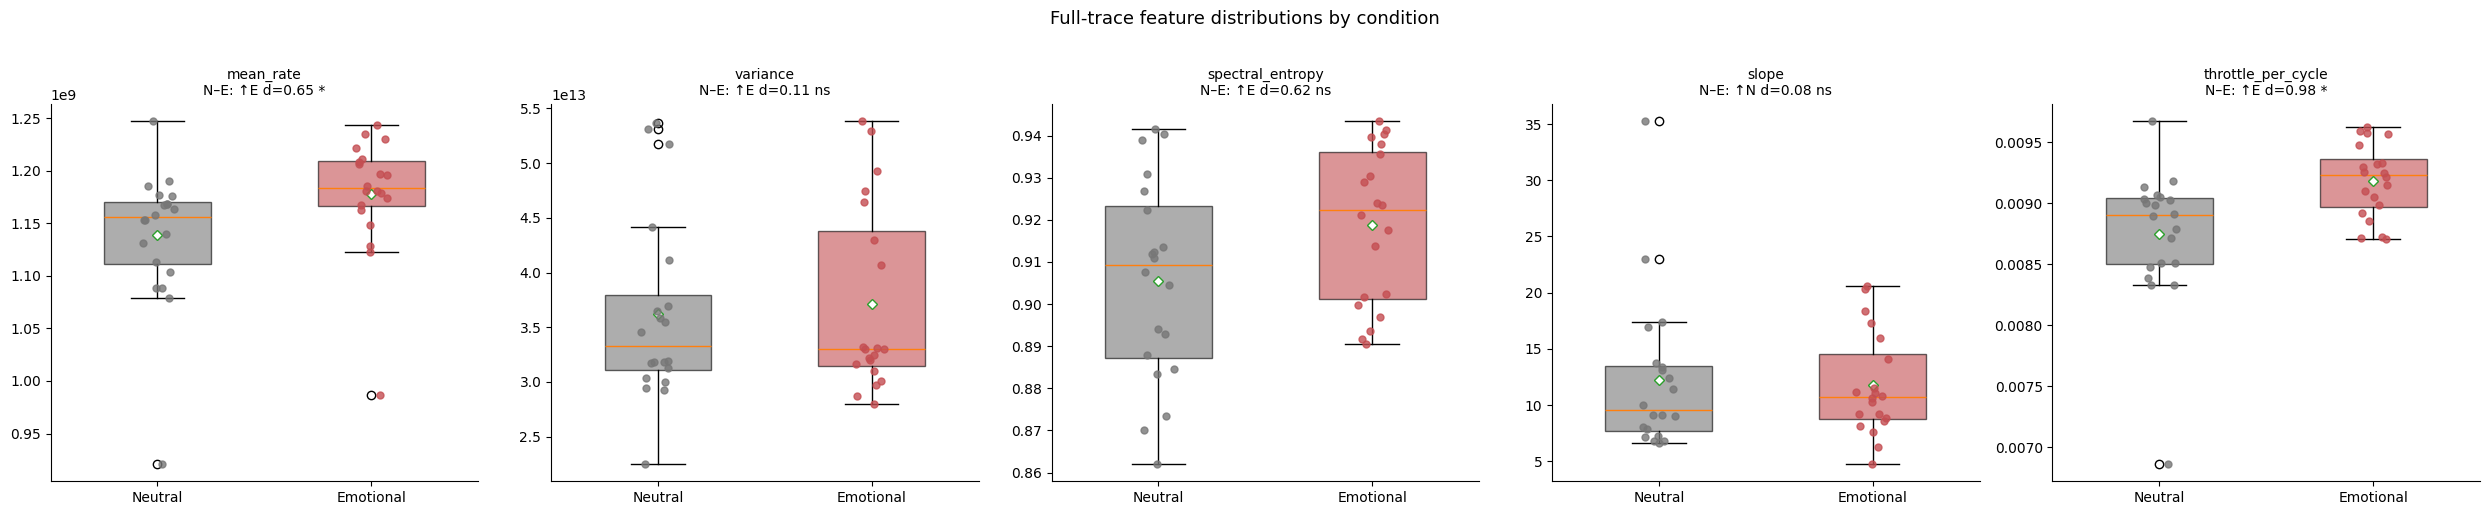

In [20]:
n_feat = len(FEATURES)
fig, axes = plt.subplots(1, n_feat, figsize=(5 * n_feat, 5), squeeze=False)
rng_j = np.random.default_rng(SEED)
for ax, feat in zip(axes[0], FEATURES):
    groups = [df.loc[df.condition == c, feat].dropna().values for c in CONDITIONS]
    positions = np.arange(len(CONDITIONS))
    bp = ax.boxplot(groups, positions=positions, widths=0.5, patch_artist=True,
                    showmeans=True, meanprops=dict(marker='D', markerfacecolor='white', markersize=5))
    for pos, cond, vals, box in zip(positions, CONDITIONS, groups, bp['boxes']):
        box.set_facecolor(COLORS[cond])
        box.set_alpha(0.6)
        ax.scatter(pos + rng_j.uniform(-0.08, 0.08, len(vals)), vals,
                   color=COLORS[cond], s=25, zorder=5, alpha=0.8)
    annotations = []
    for _, r in res_df[res_df.feature == SHORT[feat]].iterrows():
        sig = '***' if r.mwu_p_corr < 0.001 else '**' if r.mwu_p_corr < 0.01 else '*' if r.mwu_p_corr < 0.05 else 'ns'
        annotations.append(f'{r.pair}: {r.direction} d={r.cohens_d:.2f} {sig}')
    ax.set_title(SHORT[feat] + '\n' + '\n'.join(annotations), fontsize=10)
    ax.set_xticks(positions)
    ax.set_xticklabels([c.title() for c in CONDITIONS])
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Full-trace feature distributions by condition', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## §2b — Per-feature intra/inter group distances

For each feature and condition pair, compute mean within-group distances, mean cross-condition distance, and the inter/intra ratio using the same unique within-group pairs and all cross-group pairs as before.

In [21]:
dist_1d_results = []
for feat in FEATURES:
    for left, right in PAIRS:
        a = df.loc[df.condition == left, feat].dropna().values
        b = df.loc[df.condition == right, feat].dropna().values
        intra_a = np.array([abs(x-y) for x, y in combinations(a, 2)])
        intra_b = np.array([abs(x-y) for x, y in combinations(b, 2)])
        inter = np.abs(a[:, None] - b[None, :]).ravel()
        mean_intra = np.concatenate([intra_a, intra_b]).mean()
        r = res_df[(res_df.feature == SHORT[feat]) & (res_df.left == left) & (res_df.right == right)].iloc[0]
        dist_1d_results.append(dict(
            feature=SHORT[feat], left=left, right=right, pair=r.pair, direction=r.direction,
            intra_left=intra_a.mean(), intra_right=intra_b.mean(),
            intra_avg=mean_intra, inter=inter.mean(),
            ratio=inter.mean()/mean_intra if mean_intra > 0 else np.nan))
dist_1d_df = pd.DataFrame(dist_1d_results)
print(dist_1d_df.to_string(index=False))
print('Inter/Intra > 1: cross-condition pairs are farther apart on average.')
print('Inter/Intra ≈ 1: similar mean within- and cross-condition distances.')
dist_1d_df.to_csv(RESULTS_DIR / 'feature_distances.csv', index=False)


           feature    left     right pair direction   intra_left  intra_right    intra_avg        inter    ratio
         mean_rate neutral emotional  N–E        ↑E 6.531123e+07 5.548578e+07 6.039851e+07 6.806691e+07 1.126964
          variance neutral emotional  N–E        ↑E 9.235180e+12 9.270381e+12 9.252780e+12 8.958595e+12 0.968206
  spectral_entropy neutral emotional  N–E        ↑E 2.813269e-02 2.173670e-02 2.493470e-02 2.634401e-02 1.056520
             slope neutral emotional  N–E        ↑N 6.757011e+00 5.149549e+00 5.953280e+00 5.800967e+00 0.974415
throttle_per_cycle neutral emotional  N–E        ↑E 5.554725e-04 3.510794e-04 4.532760e-04 5.566460e-04 1.228051
Inter/Intra > 1: cross-condition pairs are farther apart on average.
Inter/Intra ≈ 1: similar mean within- and cross-condition distances.


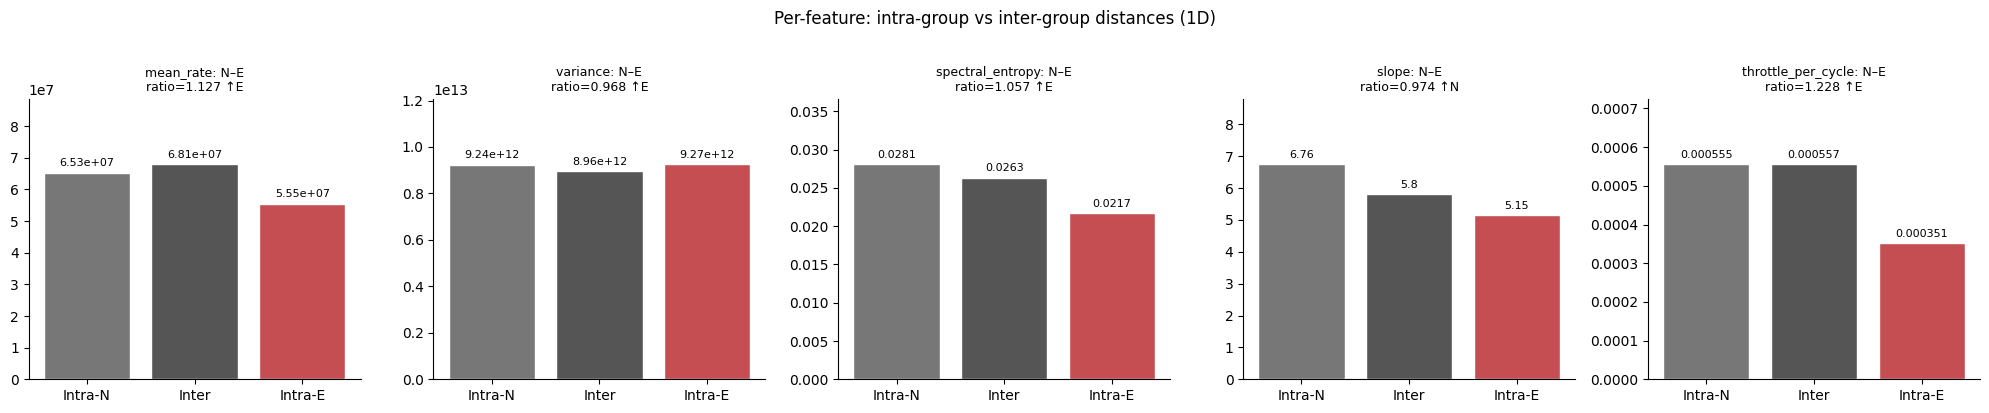

In [22]:
# Same intra/inter bars, with a row for each condition pair.
fig, axes = plt.subplots(len(PAIRS), len(FEATURES),
                         figsize=(4 * len(FEATURES), 4 * len(PAIRS)), squeeze=False)
for row_idx, (left, right) in enumerate(PAIRS):
    for col_idx, feat in enumerate(FEATURES):
        ax = axes[row_idx, col_idx]
        row = dist_1d_df[(dist_1d_df.feature == SHORT[feat]) &
                         (dist_1d_df.left == left) & (dist_1d_df.right == right)].iloc[0]
        vals = [row.intra_left, row.inter, row.intra_right]
        bars = ax.bar(range(3), vals, color=[COLORS[left], '#555555', COLORS[right]], edgecolor='white')
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, val+max(vals)*0.02,
                    f'{val:.3g}', ha='center', va='bottom', fontsize=8)
        ax.set_xticks(range(3))
        ax.set_xticklabels([f'Intra-{CODES[left]}', 'Inter', f'Intra-{CODES[right]}'])
        ax.set_title(f'{row.feature}: {row.pair}\nratio={row.ratio:.3f} {row.direction}', fontsize=9)
        ax.spines[['top', 'right']].set_visible(False)
        ax.set_ylim(0, max(vals)*1.3 if max(vals) > 0 else 1)
fig.suptitle('Per-feature: intra-group vs inter-group distances (1D)', y=1.02)
plt.tight_layout()
plt.show()

## §4 — Summary

In [23]:
print('FULL-TRACE ANALYSIS SUMMARY')
print('Traces: ' + ', '.join(f'{counts[c]} {c}' for c in CONDITIONS))
print(f'Features: {len(FEATURES)}')
print('PER-FEATURE RESULTS (Bonferroni-corrected):')
print(res_df[['feature', 'pair', 'direction', 'cohens_d', 't_p_corr', 'mwu_p_corr']].to_string(index=False))
print('PER-FEATURE DISTANCE RATIOS (inter/intra):')
print(dist_1d_df[['feature', 'pair', 'ratio', 'direction']].to_string(index=False))
print('Significant corrected Mann–Whitney comparisons:')
print(res_df.loc[res_df.mwu_p_corr < 0.05, ['feature', 'pair', 'direction', 'mwu_p_corr']].to_string(index=False))
print(f'E–N-only exploratory analysis: Bonferroni k={n_tests} per test family.')
print('Pooled batch composition and repeated-node dependence remain limitations.')


FULL-TRACE ANALYSIS SUMMARY
Traces: 20 neutral, 20 emotional
Features: 5
PER-FEATURE RESULTS (Bonferroni-corrected):
           feature pair direction  cohens_d  t_p_corr  mwu_p_corr
         mean_rate  N–E        ↑E  0.650610  0.233653    0.038559
          variance  N–E        ↑E  0.108342  1.000000    1.000000
  spectral_entropy  N–E        ↑E  0.616891  0.294737    0.429274
             slope  N–E        ↑N  0.081548  1.000000    1.000000
throttle_per_cycle  N–E        ↑E  0.980154  0.021382    0.012803
PER-FEATURE DISTANCE RATIOS (inter/intra):
           feature pair    ratio direction
         mean_rate  N–E 1.126964        ↑E
          variance  N–E 0.968206        ↑E
  spectral_entropy  N–E 1.056520        ↑E
             slope  N–E 0.974415        ↑N
throttle_per_cycle  N–E 1.228051        ↑E
Significant corrected Mann–Whitney comparisons:
           feature pair direction  mwu_p_corr
         mean_rate  N–E        ↑E    0.038559
throttle_per_cycle  N–E        ↑E    0.012803


## Prompt TTR analysis

Word-level type/token ratio uses lowercase whitespace tokens from
`independentN.json` and `independentE.json`. This retains
the original notebook's equal-variance t-test and two-sided Mann–Whitney test.
TTR depends on text length; this supplementary check does not adjust hardware
features or establish absence of workload confounding.


In [24]:
import json

def ttr(text):
    tokens = text.lower().split()
    return len(set(tokens)) / len(tokens) if tokens else 0

ttr_groups = {}
for cond in CONDITIONS:
    path = BASE_DIR / 'prompts' / '20base' / f'independent{CODES[cond]}.json'
    prompts = json.loads(path.read_text())
    ttr_groups[cond] = [ttr(p['instructions']) for p in prompts]
print('Type-to-Token Ratio (word-level)')
for cond, vals in ttr_groups.items():
    print(f'{cond.title():10s} n={len(vals):3d} mean={np.mean(vals):.4f} std={np.std(vals):.4f}')
ttr_results = []
for left, right in PAIRS:
    t, p_t = ttest_ind(ttr_groups[left], ttr_groups[right])
    u, p_u = mannwhitneyu(ttr_groups[left], ttr_groups[right], alternative='two-sided')
    ttr_results.append(dict(pair=f'{CODES[left]}–{CODES[right]}', t=t, t_p=p_t, U=u, mwu_p=p_u,
                            t_p_corr=min(p_t*len(PAIRS), 1), mwu_p_corr=min(p_u*len(PAIRS), 1)))
ttr_df = pd.DataFrame(ttr_results)
print(ttr_df.to_string(index=False))
ttr_df.to_csv(RESULTS_DIR / 'prompt_ttr_tests.csv', index=False)
print('Corrected TTR p-values use Bonferroni across the single E–N pair (multiplier 1), separately for each test family.')

Type-to-Token Ratio (word-level)
Neutral    n= 20 mean=0.6044 std=0.0367
Emotional  n= 20 mean=0.6723 std=0.0398
pair         t      t_p    U   mwu_p  t_p_corr  mwu_p_corr
 N–E -5.469825 0.000003 42.0 0.00002  0.000003     0.00002
Corrected TTR p-values use Bonferroni across the single E–N pair (multiplier 1), separately for each test family.
